In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Pre-Processing Analysis 

In [19]:
df = pd.read_csv("data/zara.csv", sep = ";")
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


In [20]:
# check for any null values or duplicates before continuing
print(f"Null values:\n{df.isnull().sum()}")
print()
print(f"Duplicates: {df.duplicated().sum()}")

Null values:
Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
sku                 0
name                1
description         2
price               0
currency            0
scraped_at          0
terms               0
section             0
dtype: int64

Duplicates: 0


### Distribution of "price" & "Sales Volume"

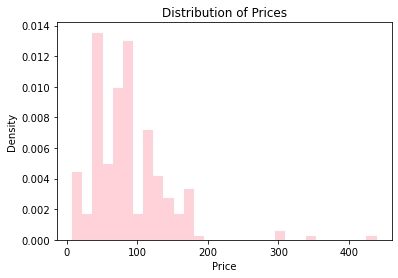

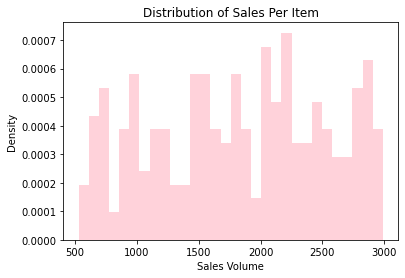

In [21]:
prices = df["price"]

plt.hist(prices, bins=30, density=True, alpha=0.7,color="pink")
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Distribution of Prices")
plt.show()

sv = df["Sales Volume"]

plt.hist(sv, bins=30, density=True, alpha=0.7,color="pink")
plt.xlabel("Sales Volume")
plt.ylabel("Density")
plt.title("Distribution of Sales Per Item")
plt.show()

Sales volume seems to fit a uniform distribution. This means there's no inherent bias towards selling more or less units of a product.

#### It seems like the prices fit a Gassian distribution, so let's fit this data to a Guassian pdf

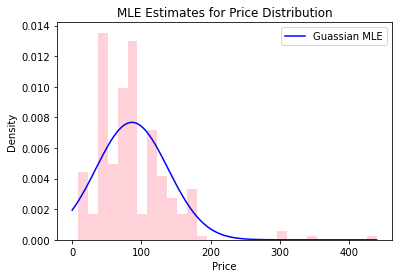

In [22]:
x_vals = np.linspace(0, max(prices), 1000)
mu = np.mean(prices)
sigma = np.std(prices)
pdf_gauss = stats.norm.pdf(x_vals, mu, sigma)

plt.hist(prices, bins=30, density=True, alpha=0.7,color="pink")
plt.plot(x_vals, pdf_gauss, label="Guassian MLE", color="blue")
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("MLE Estimates for Price Distribution")
plt.legend()
plt.show()

#### From this pdf we can see most prices at Zara/in the dataset are 100 dollars or less

### Exploring categorical data

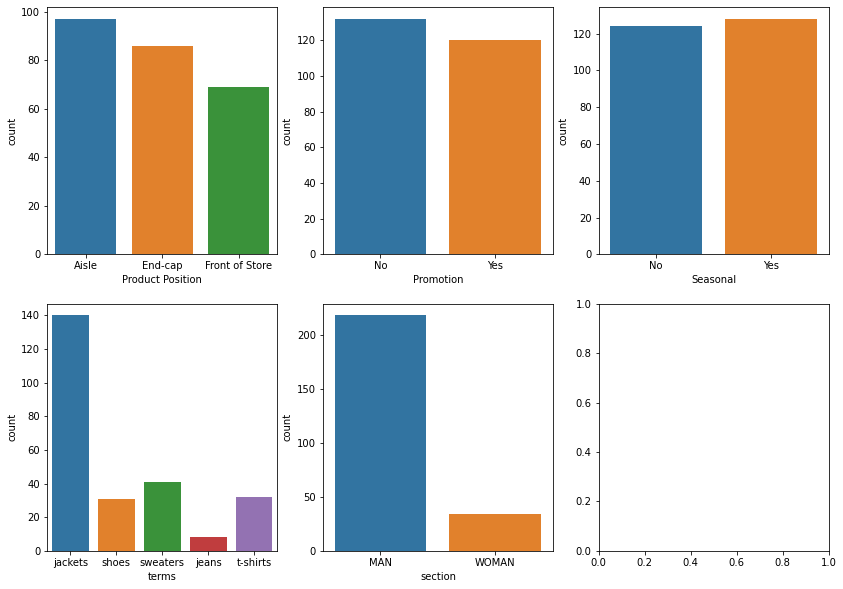

In [23]:
fig, axs = plt.subplots(2, 3, figsize=(14, 10))
sns.countplot(x = 'Product Position', data = df, ax = axs[0,0]);
sns.countplot(x = 'Promotion',data = df, ax = axs[0,1] );
sns.countplot(x = 'Seasonal',data = df, ax = axs[0,2] );
sns.countplot(x = 'terms',data = df ,ax = axs[1,0] );
sns.countplot(x = 'section',data = df ,ax = axs[1,1] );

### This data gives a few pieces of info about the products in the dataset
#### Product Positon: While fairly uniform, there are more products in the Aisle
#### Promotion: About half the products are promotional and half are not
#### Seasonal: About half the products are seasonal and half are not
#### Terms: More jackets than any other clothing type
#### Section: More men's clothing than women's


#### Since I personally know Zara sells more woman's clothing, it's clear this dataset does not provide a fully accurate depiction of Zara Sales. Because of this we will compare averages to account for this.

### Exploring categorical data average revenue

In [24]:
# create total column based on price and sales volume
df["Total"] = df["price"] * df["Sales Volume"]
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section,Total
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN,56431.77
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN,110526.00
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN,286380.00
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN,202272.00
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN,408938.00


In [25]:
pd.DataFrame(df.groupby("Product Position")["Total"].mean().sort_values(ascending = False))

,Total
Product Position,
Aisle,159602.458041
Front of Store,158848.873043
End-cap,145889.137326


Take Away: Products in the Aisle generate the most revenue

In [26]:
pd.DataFrame(df.groupby("Promotion")["Total"].mean().sort_values(ascending = False))

,Total
Promotion,
Yes,166619.890833
No,143894.618030


Take Away: Promotional products generate 15.79% more revenue than non-promotional products

In [27]:
pd.DataFrame(df.groupby("Seasonal")["Total"].mean().sort_values(ascending = False))

,Total
Seasonal,
Yes,154938.192656
No,154486.998548


Take Away: Seasonal products generate a slightly higher revenue than non seasonal, but the difference is marginal (0.29%)

In [28]:
pd.DataFrame(df.groupby("terms")["Total"].mean().sort_values(ascending = False))

,Total
terms,
jackets,189870.113357
shoes,121123.794516
t-shirts,115525.195313
jeans,108048.156250
sweaters,99771.499512


Take Away: Jackets generate the highest revenue making up 29.93% of the average revenue, following is shoes (19.09%), t-shirts (18.21%), jeans (17.03%), and sweaters (15.72%)

In [29]:
pd.DataFrame(df.groupby("section")["Total"].mean().sort_values(ascending = False))

,Total
section,
MAN,163819.555183
WOMAN,96347.454412


Take Away: Men's clothing generate 70% more revenue than women's clothing. This is interesting because even though we have taken into account the larger amount of men's products in the dataset, there still is a large difference in avg revenue between the two sections.

## Processing Data for Gradient Descent

## Predict Total Revenue

#### based on price, position, promotional, seasonal, terms, and section

In [30]:
y = np.vstack(df["Total"])
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(np.vstack(df["Total"]))
raw_zara = df.drop(columns = ["Product ID", "Sales Volume", "Product Category", "brand", "url", "sku", "name","description", "currency", "scraped_at", "Total"])
one_hot_zara = pd.get_dummies(raw_zara, drop_first = True, dtype=float)
zara_scaled = MinMaxScaler().fit_transform(one_hot_zara).round(2)
phi = np.hstack([zara_scaled, np.ones((zara_scaled.shape[0], 1))])
one_hot_zara

,price,Product Position_End-cap,Product Position_Front of Store,Promotion_Yes,Seasonal_Yes,terms_jeans,terms_shoes,terms_sweaters,terms_t-shirts,section_WOMAN
0,19.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,169.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,129.00,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,129.00,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,139.00,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
247,169.00,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
248,159.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
249,12.99,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
250,19.90,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [31]:
ridge = Ridge(alpha=1.0)
ridge.fit(phi, y_scaled) 

y_pred_scaled = ridge.predict(phi)

loss_ridge = mean_squared_error(y_scaled, y_pred_scaled)
r2_ridge = r2_score(y_scaled, y_pred_scaled)
wR = ridge.coef_.flatten() 

print("Loss Ridge (MSE):", loss_ridge)
print("R2 score: ", r2_ridge)
print(wR)

Loss Ridge (MSE): 0.012372793588864549
R2 score:  0.5457590501092917
[ 7.45934253e-01 -5.51839276e-03 -3.93356507e-03  1.33053900e-02
  1.79269700e-03 -4.40780167e-02 -3.36735192e-02 -4.87846483e-02
 -4.53948233e-02  2.10727038e-04  0.00000000e+00]


In [32]:
wC = np.dot(np.linalg.inv(np.dot(phi.T, phi)), np.dot(phi.T, y_scaled))
n = phi.shape[0]
y_pred_scaled = np.dot(phi, wC)
p_closed = (y_pred_scaled - y_scaled)
loss_closed = (1/n)*np.dot(np.transpose(p_closed), p_closed).item()

r2_closed = r2_score(y_scaled, y_pred_scaled)
print("Loss Closed Form (MSE):", loss_closed)
print("R2 score: ", r2_closed)
print(wC)

Loss Closed Form (MSE): 0.011641016394273394
R2 score:  0.5726247022024946
[[ 0.99682144]
 [-0.00246027]
 [-0.00361987]
 [ 0.00630203]
 [ 0.00246219]
 [-0.0275008 ]
 [-0.01200089]
 [-0.04300466]
 [-0.02578618]
 [ 0.02482225]
 [ 0.05951279]]


#### After training the model with Ridge Regression and the Closed Form Solution, it appears the loss from the closed form solution is slightly lower and the R2 score is slightly higher, so we will continue with the closed-form solution to analyze the predictions.

In [33]:
labels = [
    "Price",
    "Product Position_End-cap",
    "Product Position_Front of Store",
    "Promotion_Yes",
    "Seasonal_Yes",
    "terms_jeans",
    "terms_shoes",
    "terms_sweaters",
    "terms_t-shirts",
    "section_WOMAN",
    "Bias"
]

for i, label in enumerate(labels):
    print(f"{label}: {wC[i][0]:.4f}")


Price: 0.9968
Product Position_End-cap: -0.0025
Product Position_Front of Store: -0.0036
Promotion_Yes: 0.0063
Seasonal_Yes: 0.0025
terms_jeans: -0.0275
terms_shoes: -0.0120
terms_sweaters: -0.0430
terms_t-shirts: -0.0258
section_WOMAN: 0.0248
Bias: 0.0595


Take aways: Price dominates the model, having the most positive effect on total revenue of a product which makes sense considering half the equation of revenue is price. Products in the Aisle generate more revenue compared to the end-cap and front of the store. Seasonal and Promotional items contribute to a higher revenue compared to non-seasonal and non-promotional items. Jackets generate more revenue than jeans, shoes, sweaters and t-shirts, and sweaters perform the worst while shoes perform the best in comparison to jackets. The Woman's section outperforms the men's section. This is interesting because before training the model we saw that men's avg revenue dominated women's but after training the model we see a more accurate picture of how the sections truly compare.

### Predicting total revenue of ten random items in the dataset

In [35]:
import random
import numpy as np

random_indices = random.sample(range(phi.shape[0]), 10)

def f(x, w):
    return sum(w[i, 0] * x[i] for i in range(len(x))) + w[10, 0]

results = []

for idx in random_indices:
    x = phi[idx]
    predicted_scaled = np.array([[f(x, wC)]])
    predicted_unscaled = scaler_y.inverse_transform(predicted_scaled)[0][0]
    actual_unscaled = df["Total"].iloc[idx]
    abs_diff = abs(predicted_unscaled - actual_unscaled)
    results.append((idx, predicted_unscaled, actual_unscaled, abs_diff))

print(f"{'Index':<6} {'Predicted':>12} {'Actual':>12} {'Abs Diff':>12}")
print("-" * 48)
for idx, pred, actual, diff in results:
    print(f"{idx:<6} {pred:>12.2f} {actual:>12.2f} {diff:>12.2f}")


Index     Predicted       Actual     Abs Diff
------------------------------------------------
90        100716.80     35382.30     65334.50
219       122736.22     54529.20     68207.02
19        305567.19    106371.00    199196.19
3         267672.24    202272.00     65400.24
143       197907.13    221693.40     23786.27
89        173274.97     79336.50     93938.47
217       113912.17     78922.20     34989.97
215       112319.91     36588.30     75731.61
24        321797.98    257556.00     64241.98
245       235415.57    238383.00      2967.43
